# Task 9 — Data Processing Pipeline


---

## Raw Data Sources
| Source | Table | Description |
|--------|-------|-------------|
| MSFT.csv + Microsoft_2025-2026.csv | `msft_daily` | Microsoft daily OHLCV stock data (2019-2026) |
| Gold.csv + Gold_2025-2026.csv | `gold_prices` | Daily gold closing price (2019-2026) |
| CrudeOil.csv + Oil_2025-2026.csv | `oil_prices` | Daily crude oil closing price (2019-2026) |
| MacroEconomicIndicators.csv + VIX_2025-2026.csv | `vix_data` | Daily VIX values (2019-2026) |

## Pipeline Steps
1. Import from production script
2. Load Data from Database
3. Merge All Datasets
4. Handle Missing Values
5. Create Target Column (0.5% threshold)
6. Engineer Features
7. Scale Features (RobustScaler)
8. Train/Test Split
9. Save Processed Features to Database
10. Verify Pipeline Output

## 1. Import from Production Script
All pipeline logic is defined in `pipeline/preprocess.py`.  
This notebook imports and calls those functions — no duplicate code.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


from pipeline.preprocess import (
    load_all_tables,
    merge_datasets,
    handle_missing_values,
    create_target,
    engineer_features,
    scale_features,
    train_test_split_timeseries,
    save_processed_features,
    FEATURE_COLS,
    DB_PATH,
)

print('All imports successful')
print(f'Database path : {DB_PATH}')
print(f'Feature count : {len(FEATURE_COLS)}')

All imports successful
Database path : data/stocks.db
Feature count : 16


## 2. Load Data from Database
All data is loaded directly from `stocks.db`.  
No raw CSV files are read in this notebook — all data comes through the database.

In [2]:
msft_df, gold_df, oil_df, vix_df = load_all_tables(DB_PATH)

print('Data loaded from database:')
print(f'  msft_daily  : {len(msft_df)} rows')
print(f'  gold_prices : {len(gold_df)} rows')
print(f'  oil_prices  : {len(oil_df)} rows')
print(f'  vix_data    : {len(vix_df)} rows')

2026-05-14 18:14:11,178 - INFO - Loaded from database: msft=1842, gold=1843, oil=1843, vix=1863


Data loaded from database:
  msft_daily  : 1842 rows
  gold_prices : 1843 rows
  oil_prices  : 1843 rows
  vix_data    : 1863 rows


## 3. Merge All Datasets
Merge all four tables on the `date` column using left joins.  
MSFT trading days are the base — gold, oil, and VIX are joined to each trading day.

In [3]:
df = merge_datasets(msft_df, gold_df, oil_df, vix_df)

print(f'Merged shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nMissing values after merge:')
print(df.isnull().sum())
df.head(5)

2026-05-14 18:14:11,200 - INFO - Merged dataset shape: (1842, 9)


Merged shape: (1842, 9)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'gold_close', 'oil_close', 'vix']

Missing values after merge:
date          0
open          0
high          0
low           0
close         0
volume        0
gold_close    0
oil_close     0
vix           0
dtype: int64


,date,open,high,low,close,volume,gold_close,oil_close,vix
0,2019-01-02,99.55,101.7500,98.9400,101.12,35329345.0,1281.000000,46.540001,23.22
1,2019-01-03,100.10,100.1850,97.2000,97.40,42578410.0,1291.800049,47.090000,25.45
2,2019-01-04,99.72,102.5100,98.9300,101.93,44060590.0,1282.699951,47.959999,21.38
3,2019-01-07,101.64,103.2681,100.9800,102.06,35656136.0,1286.800049,48.520000,21.40
4,2019-01-08,103.04,103.9700,101.7134,102.80,31514415.0,1283.199951,49.779999,20.47


## 4. Handle Missing Values
Forward fill gaps in gold, oil, and VIX caused by trading calendar misalignments.  
Any remaining rows with NaN are dropped.

In [4]:
df = handle_missing_values(df)

print(f'Rows after handling missing values: {len(df)}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('\nSample:')
df[['date', 'close', 'gold_close', 'oil_close', 'vix']].head(5)

2026-05-14 18:14:11,221 - INFO - Missing values handled. Dropped 0 rows.


Rows after handling missing values: 1842
Missing values remaining: 0

Sample:


,date,close,gold_close,oil_close,vix
0,2019-01-02,101.12,1281.000000,46.540001,23.22
1,2019-01-03,97.40,1291.800049,47.090000,25.45
2,2019-01-04,101.93,1282.699951,47.959999,21.38
3,2019-01-07,102.06,1286.800049,48.520000,21.40
4,2019-01-08,102.80,1283.199951,49.779999,20.47


## 5. Create Target Column
Binary target using 0.5% threshold:  
- **1 (UP)** if next day return > +0.5%  
- **0 (DOWN)** if next day return < -0.5%  
- Neutral days removed

2026-05-14 18:14:11,242 - INFO - Target created with 0.5% threshold. Dropped 552 neutral rows. UP: 705, DOWN: 585


Rows after target creation: 1290

Target distribution:
  UP   (1): 705 days (54.7%)
  DOWN (0): 585 days (45.3%)


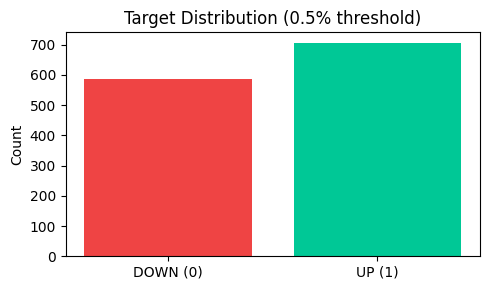

In [5]:
df = create_target(df)

print(f'Rows after target creation: {len(df)}')
print(f'\nTarget distribution:')
print(f'  UP   (1): {(df["target"]==1).sum()} days ({(df["target"]==1).mean()*100:.1f}%)')
print(f'  DOWN (0): {(df["target"]==0).sum()} days ({(df["target"]==0).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 3))
counts = df['target'].value_counts().sort_index()
ax.bar(['DOWN (0)', 'UP (1)'], counts.values, color=['#EF4444', '#00C896'])
ax.set_title('Target Distribution (0.5% threshold)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 6. Engineer Features
8 additional features to capture temporal patterns:  
lag_1, lag_2, rolling_5, rolling_10, daily_return, price_range, gold_return, oil_return

In [6]:
df = engineer_features(df)

print(f'Rows after feature engineering: {len(df)}')
print(f'\nAll features ({len(FEATURE_COLS)} total):')
for i, f in enumerate(FEATURE_COLS):
    print(f'  {i+1:2}. {f}')

2026-05-14 18:14:11,314 - INFO - Feature engineering complete. Dropped 9 rows from rolling windows. Final shape: (1281, 19)


Rows after feature engineering: 1281

All features (16 total):
   1. open
   2. high
   3. low
   4. close
   5. volume
   6. gold_close
   7. oil_close
   8. vix
   9. lag_1
  10. lag_2
  11. rolling_5
  12. rolling_10
  13. daily_return
  14. price_range
  15. gold_return
  16. oil_return


## 7. Scale Features
RobustScaler fitted on training data only to prevent data leakage.  
Scaler saved to `models/scaler.pkl` for reuse by the dashboard.

In [7]:
df, scaler = scale_features(df, FEATURE_COLS)

print(f'RobustScaler fitted and saved')
print(f'Total columns now: {len(df.columns)}')

2026-05-14 18:14:11,334 - INFO - RobustScaler fitted on 1024 training rows. Saved to models/scaler.pkl.


RobustScaler fitted and saved
Total columns now: 35


## 8. Train/Test Split
Time-based 80/20 split — no shuffling to preserve temporal structure.

2026-05-14 18:14:11,352 - INFO - Time-based split: train=1024 rows (2019-01-17 to test=257 rows (2024-09-30 to 2026-04-29)


Train size : 1024 rows
Test size  : 257 rows
Train period: 2019-01-17 to 2024-09-27
Test period : 2024-09-30 to 2026-04-29

Train UP ratio: 55.5%
Test  UP ratio: 51.4%


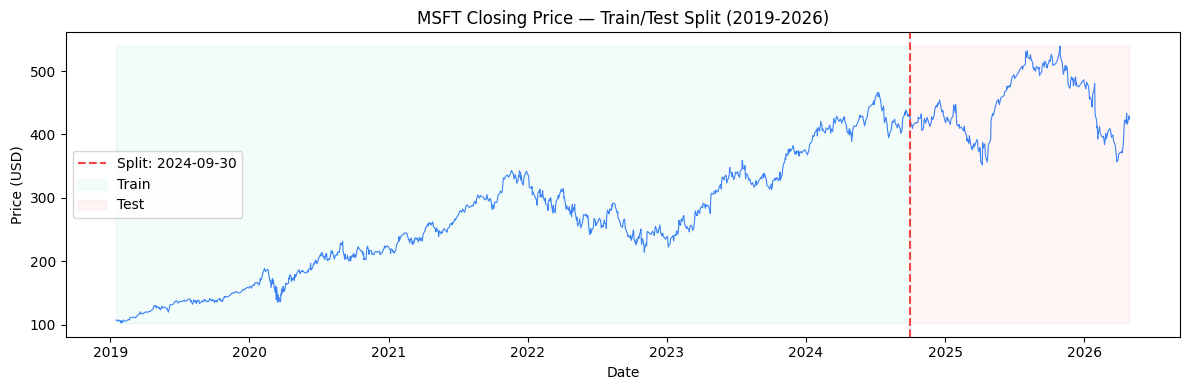

In [8]:
X_train, X_test, y_train, y_test, train_df, test_df = train_test_split_timeseries(
    df, FEATURE_COLS
)

split_date = test_df['date'].iloc[0]

print(f'Train size : {len(X_train)} rows')
print(f'Test size  : {len(X_test)} rows')
print(f'Train period: {train_df["date"].iloc[0].date()} to {train_df["date"].iloc[-1].date()}')
print(f'Test period : {test_df["date"].iloc[0].date()} to {test_df["date"].iloc[-1].date()}')
print(f'\nTrain UP ratio: {y_train.mean()*100:.1f}%')
print(f'Test  UP ratio: {y_test.mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['date'], df['close'], color='#3B82F6', linewidth=0.8)
ax.axvline(x=split_date, color='#EF4444', linestyle='--',
           linewidth=1.5, label=f'Split: {split_date.date()}')
ax.fill_betweenx(
    [df['close'].min(), df['close'].max()],
    df['date'].iloc[0], split_date,
    alpha=0.05, color='#00C896', label='Train'
)
ax.fill_betweenx(
    [df['close'].min(), df['close'].max()],
    split_date, df['date'].iloc[-1],
    alpha=0.05, color='#EF4444', label='Test'
)
ax.set_title('MSFT Closing Price — Train/Test Split (2019-2026)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Save Processed Features to Database
Processed features saved to the `processed_features` table.  
The model notebook (Task 10) reads directly from this table.

In [9]:
save_processed_features(df, FEATURE_COLS, DB_PATH)

print(f'Processed features saved to database')
print(f'Rows saved: {len(df)}')

2026-05-14 18:14:11,440 - INFO - Saved 1281 rows to processed_features table.


Processed features saved to database
Rows saved: 1281


## 10. Verify Pipeline Output

In [10]:
conn = sqlite3.connect(DB_PATH)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('All tables in database:')
for table in tables['name']:
    count = pd.read_sql(f'SELECT COUNT(*) as count FROM {table}', conn)
    rows = count['count'].values[0]
    status = '(empty)' if rows == 0 else f'{rows} rows'
    print(f'  {table:<25} {status}')
conn.close()

print('\n' + '=' * 45)
print('PIPELINE SUMMARY')
print('=' * 45)
print(f'Data range         : 2019-01-01 to 2026-04-30')
print(f'Raw data sources   : 4 tables')
print(f'Final rows         : {len(df)}')
print(f'Features           : {len(FEATURE_COLS)}')
print(f'Scaler             : RobustScaler')
print(f'Target threshold   : 0.5%')
print(f'UP days            : {(df["target"]==1).sum()} ({(df["target"]==1).mean()*100:.1f}%)')
print(f'DOWN days          : {(df["target"]==0).sum()} ({(df["target"]==0).mean()*100:.1f}%)')
print(f'Train samples      : {len(X_train)}')
print(f'Test samples       : {len(X_test)}')
print(f'Scaler saved       : models/scaler.pkl')
print(f'Database updated   : processed_features table')
print('=' * 45)
print('Task 9 complete — ready for Task 10 (Model Training)')

All tables in database:
  predictions               (empty)
  msft_daily                1842 rows
  gold_prices               1843 rows
  oil_prices                1843 rows
  vix_data                  1863 rows
  processed_features        1281 rows

PIPELINE SUMMARY
Data range         : 2019-01-01 to 2026-04-30
Raw data sources   : 4 tables
Final rows         : 1281
Features           : 16
Scaler             : RobustScaler
Target threshold   : 0.5%
UP days            : 700 (54.6%)
DOWN days          : 581 (45.4%)
Train samples      : 1024
Test samples       : 257
Scaler saved       : models/scaler.pkl
Database updated   : processed_features table
Task 9 complete — ready for Task 10 (Model Training)
